# SpaPath breast cancer workflow

This notebook follows one linear workflow: load healthy and disease data, attach image embeddings, preprocess and build graphs, learn initial embeddings, cluster, integrate, detect pathological regions, and identify signature genes.

## 0. Setup

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import spapath_model
import spapath_utils

warnings.filterwarnings("ignore")

In [2]:
DATASET_ID = "BC"
HEALTHY_SECTION = "V07"
DISEASE_SECTION = "H1"
DEVICE = "cuda"
SEED = 123

DATA_ROOT = Path("/share/data/wuyd")
PROCESSED_DIR = DATA_ROOT / "SpaPAD" / "processed" / DATASET_ID
OUTPUT_DIR = DATA_ROOT / "SpaPAD" / "outs" / DATASET_ID
FIGURE_DIR = OUTPUT_DIR / "fig"

for output_path in (OUTPUT_DIR, FIGURE_DIR):
    spapath_utils.create_dir(output_path)

adata_type_map = {
    HEALTHY_SECTION: "ST_with_HE",
    DISEASE_SECTION: "ST_with_HE",
}
sections = list(adata_type_map)

/share/data/wuyd/SpaPAD/outs/BC has been created or already exists.
/share/data/wuyd/SpaPAD/outs/BC/fig has been created or already exists.


## 1. Read healthy and disease data

In [3]:
healthy_adata = sc.read_h5ad(PROCESSED_DIR / f"{HEALTHY_SECTION}.h5ad")
disease_adata = sc.read_h5ad(PROCESSED_DIR / f"{DISEASE_SECTION}.h5ad")

datasets = {
    HEALTHY_SECTION: healthy_adata,
    DISEASE_SECTION: disease_adata,
}

## 2. Attach image embeddings

In [ ]:
for section, adata in datasets.items():
    embedding_path = (
        PROCESSED_DIR / "spatial" / f"{section}_image_embeddings.csv"
    )
    spapath_utils.attach_image_embedding(adata, embedding_path)

## 3. Preprocess data and build graphs

In [5]:
batch_list = [healthy_adata, disease_adata]
adata_full, disease_adata_all_genes = spapath_utils.preprocess(
    adata_list=batch_list,
    adata_type_map=adata_type_map,
    full_num_hvgs=3000,
    min_genes_qc=10,
    min_cells_qc=10,
)

adata_full = spapath_utils.build_graph_GAT_plus(
    adata_full=adata_full,
    adata_type_map=adata_type_map,
    K=8,
    img_threshold=0.0,
)

shape of adata 0 before quality control: (2086, 36393)
shape of adata 0 after quality control: (2086, 13642)
shape of adata 1 before quality control: (530, 15029)
shape of adata 1 after quality control: (530, 8721)
Find 7978 shared genes among datasets.
Normalize data...
Find 3000 shared highly variable genes among datasets.
Start building graphs...
Building sparse graph for batch V07 (ST_with_HE) using NearestNeighbors...
  Image similarity quantiles (neighbors only): [-0.78292766  0.08484013  0.33256572  0.63993939  1.        ]
  Average neighbors for Slice V07: 6.41
Building sparse graph for batch H1 (ST_with_HE) using NearestNeighbors...
  Image similarity quantiles (neighbors only): [-0.578242    0.03440647  0.36520232  0.64929606  1.        ]
  Average neighbors for Slice H1: 5.97


## 4. Learn initial embeddings

In [7]:
model = spapath_model.Model(
    adata_full=adata_full,
    adata_type_map=adata_type_map,
    lr_pre=1e-4,
    lr=1e-4,
    n_pre_training_steps=500,
    n_training_steps=300,
    device=DEVICE,
    seed=SEED,
)

adata_full = model.initial_embedding()

Pretrain slice 1: 100%|██████████| 500/500 [00:00<00:00, 548.77it/s]


## 5. Cluster observations

In [8]:
adata_full = model.clustering(
    init_res=1.5,
    intopk=40,
)

There are 16 initial clusters for Slice - 0
There are 13 initial clusters for Slice - 1
There are 7 clusters for Slice - 0 after merging.
There are 9 clusters for Slice - 1 after merging.
[Cluster size] Slice 0 after merge: 0:361(0.173), 1:615(0.295), 2:439(0.210), 3:353(0.169), 4:142(0.068), 5:118(0.057), 6:58(0.028)
[Cluster size] Slice 1 after merge: 0:250(0.472), 1:56(0.106), 2:50(0.094), 3:38(0.072), 4:33(0.062), 5:32(0.060), 6:31(0.058), 7:29(0.055), 8:11(0.021)
Skip Deep Embedded Clustering (DEC) fine-tuning.
Add cluster size diagnostics into adata_full.uns['cluster_size_diagnostics'].


## 6. Integrate healthy and disease data

In [9]:
adata_full = model.integrate(topk=40)

Loaded weights for slice 0
Loaded weights for slice 1


  0%|          | 1/300 [00:00<02:18,  2.16it/s]

Matched target clusters: [2]
[{1, 3, 4, 5, 6, 8}]
Global far candidates: [1, 3, 4, 5, 6, 8]
Global far pool: [4]
Ref 0 eligible anchors (min_frac=0.05): [0, 1, 2, 3, 4, 5]; filtered: [6]
Ref 0 pair pool:
  Ref Tar         Score
0   1   2  3.716241e-24
[Train] Step: 0,recon_loss: 32.8012, inter_loss: 2.3136,intra_loss: 6.5081,geom_loss: 454.6693


 36%|███▌      | 107/300 [00:04<00:08, 22.77it/s]

Matched target clusters: [0, 2, 7]
[{1, 3, 4, 5, 6, 8}]
Global far candidates: [1, 3, 4, 5, 6, 8]
Global far pool: [3, 4, 5, 6, 8]
Ref 0 eligible anchors (min_frac=0.05): [0, 1, 2, 3, 4, 5]; filtered: [6]
Ref 0 pair pool:
  Ref Tar         Score
0   1   2  3.716241e-24
1   3   0  2.385770e-08
2   0   7  1.590513e-08
[Train] Step: 100,recon_loss: 33.0688, inter_loss: 0.2182,intra_loss: 6.7262,geom_loss: 80.0375


 68%|██████▊   | 205/300 [00:08<00:04, 20.96it/s]

Matched target clusters: [0, 2, 7]
[{1, 3, 4, 5, 6, 8}]
Global far candidates: [1, 3, 4, 5, 6, 8]
Global far pool: [1, 3, 4, 5, 6, 8]
Ref 0 eligible anchors (min_frac=0.05): [0, 1, 2, 3, 4, 5]; filtered: [6]
Ref 0 pair pool:
  Ref Tar         Score
0   1   2  3.716241e-24
1   3   0  2.385770e-08
2   0   7  1.590513e-08
3   2   2  1.597912e-02
4   2   0  6.847272e-04
[Train] Step: 200,recon_loss: 32.7497, inter_loss: 0.0209,intra_loss: 6.8331,geom_loss: 57.3937


100%|██████████| 300/300 [00:12<00:00, 24.41it/s]


Add cell/spot embeddings into adata_full.obsm[cell_embed]...
Add gene embedding in adata_full.uns.....
Add gene embedding in adata_full.uns.....
Add gene cell_gene distance in adata_full.layers[cell_gene_dist]......


## 7. Detect pathological regions

In [ ]:
adata_full = spapath_utils.detection(
    adata=adata_full,
    embed="cell_embed",
    section_ids=sections,
    label_core="Pathological regions",
    label_other="Healthy-like regions",
    core_types=["cancer in situ", "invasive cancer"],
    celltype_key="CellType",
    batch_key="batch",
    seed=SEED,
    neighbors=30,
    threshold=0.05,
    strategy="individual",
)

display(adata_full.uns["result"])

In [ ]:
detection_figure = spapath_utils.plot_detection_umap(
    adata=adata_full,
    embed="cell_embed",
    section_id=DISEASE_SECTION,
    batch_key="batch",
    label_key="pred_label",
    celltype_key="CellType",
    seed=SEED,
    point_size=18,
    save=FIGURE_DIR / f"{DISEASE_SECTION}_detection_umap.png",
)

## 8. Identify and display signature genes

In [11]:
disease_mask = adata_full.obs["batch"] == DISEASE_SECTION
disease_result = adata_full[disease_mask].copy()
disease_result.obsm["X_spatial_plot"] = disease_result.obsm["spatial"].copy()
disease_result.obsm["X_spatial_plot"][:, 1] *= -1

signature_results = spapath_utils.select_sig_genes(
    adata=disease_result,
    dist_key="cell_gene_dist",
    label_key="pred_label",
    topk=100,
)

pathological_signature_genes = signature_results[
    "Pathological regions"
]["genes"]
signature_table = pd.DataFrame(
    {
        "rank": np.arange(1, len(pathological_signature_genes) + 1),
        "gene": pathological_signature_genes,
    }
)
display(signature_table.head(20))

,rank,gene
0,1,HSPH1
1,2,ITGB6
2,3,SMC4
3,4,CCDC88C
4,5,OSGIN2
5,6,PBRM1
6,7,TPGS2
7,8,PEG10
8,9,PUM2
9,10,ENC1


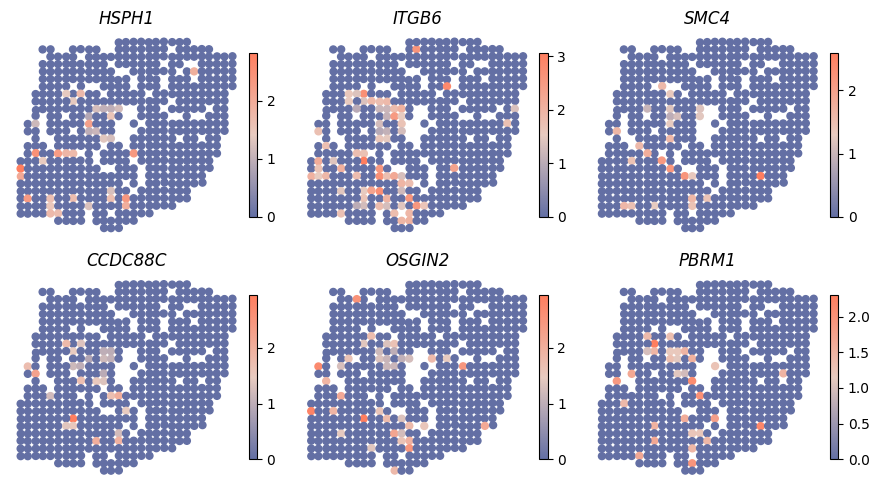

In [12]:
genes_to_plot = pathological_signature_genes[:6]
if not genes_to_plot:
    raise RuntimeError("No pathological-region signature genes were identified.")

n_columns = 3
n_rows = int(np.ceil(len(genes_to_plot) / n_columns))
figure, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(n_columns * 3, n_rows * 2.5),
    squeeze=False,
)
axes = axes.ravel()
coordinates = disease_result.obsm["X_spatial_plot"]
signature_cmap = LinearSegmentedColormap.from_list(
    "signature_expression", ["#636fa4", "#e8cbc0", "#ff7e5f"]
)

for axis, gene in zip(axes, genes_to_plot):
    expression = disease_result[:, gene].X
    if sp.issparse(expression):
        expression = expression.toarray()
    expression = np.asarray(expression).ravel()

    scatter = axis.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        c=expression,
        cmap=signature_cmap,
        s=25,
        rasterized=True,
    )
    axis.set_title(gene, fontsize=12, fontstyle="italic")
    axis.set_axis_off()
    figure.colorbar(scatter, ax=axis, shrink=0.8, pad=0.02)

for axis in axes[len(genes_to_plot):]:
    axis.set_visible(False)

figure.tight_layout()
figure.savefig(
    FIGURE_DIR / f"{DISEASE_SECTION}_signature_genes.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()